In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Paths
processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"
train_path = os.path.join(processed_path, 'train')
test_path  = os.path.join(processed_path, 'test')
model_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model"

# Settings
IMG_SIZE    = 48
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 3
CLASSES     = ['happiness', 'neutral', 'sadness']

print("Libraries imported successfully!")
print(f"Train path: {train_path}")
print(f"Test path : {test_path}")

Libraries imported successfully!
Train path: C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed\train
Test path : C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed\test


In [2]:
# Train data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize 0-1
    rotation_range=15,         # Slight rotation
    width_shift_range=0.1,     # Horizontal shift
    height_shift_range=0.1,    # Vertical shift
    horizontal_flip=True,      # Mirror image
    zoom_range=0.1,            # Slight zoom
    fill_mode='nearest'        # Fill empty pixels
)

# Test data generator (only normalize, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

# Compute class weights (sadness acha detect ho)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Class weights: {class_weights}")
print(f"\nTrain samples: {train_generator.samples}")
print(f"Test samples : {test_generator.samples}")

Found 31213 images belonging to 3 classes.
Found 4480 images belonging to 3 classes.

Class indices: {'happiness': 0, 'neutral': 1, 'sadness': 2}
Class weights: {0: np.float64(0.9632750054007345), 1: np.float64(1.008660526740992), 2: np.float64(1.030438083919316)}

Train samples: 31213
Test samples : 4480


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization, 
                                      Dropout, Flatten, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import regularizers

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001),
           input_shape=(48, 48, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fully connected layers
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(NUM_CLASSES, activation='softmax')
])

# Label smoothing - sadness/neutral confusion kam karne k liye
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

c:\Users\Bushra Shahid\Desktop\IDVS\ml_venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,502,947 (5.73 MB)

 Trainable params: 1,501,283 (5.73 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [4]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Create model directory if not exists
os.makedirs(model_path, exist_ok=True)

# Callbacks
callbacks = [
    # Stop training if val_loss na sudre 10 epochs tak
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Learning rate kam karo agar val_loss na sudre 5 epochs tak
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    
    # Save best model automatically
    ModelCheckpoint(
        filepath=os.path.join(model_path, 'fer_best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.3928 - loss: 2.3129
Epoch 1: val_accuracy improved from None to 0.52210, saving model to C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model\fer_best_model.keras

Epoch 1: finished saving model to C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model\fer_best_model.keras
976/976 ━━━━━━━━━━━━━━━━━━━━ 493s 493ms/step - accuracy: 0.3928 - loss: 2.3129 - val_accuracy: 0.5221 - val_loss: 1.9077 - learning_rate: 5.0000e-04
Epoch 2/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5306 - loss: 1.8013
Epoch 2: val_accuracy improved from 0.52210 to 0.62143, saving model to C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model\fer_best_model.keras

Epoch 2: finished saving model to C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model\fer_best_model.keras
976/976 ━━━━━━━━━━━━━━━━━━━━ 357s 366ms/step - accuracy: 0.5306 - loss: 1.8013 - val_accuracy: 0.6214 - val_loss: 1.5723 - learning_rate: 5.0000e-04
Epoch 3/50
976/976 ━━━━

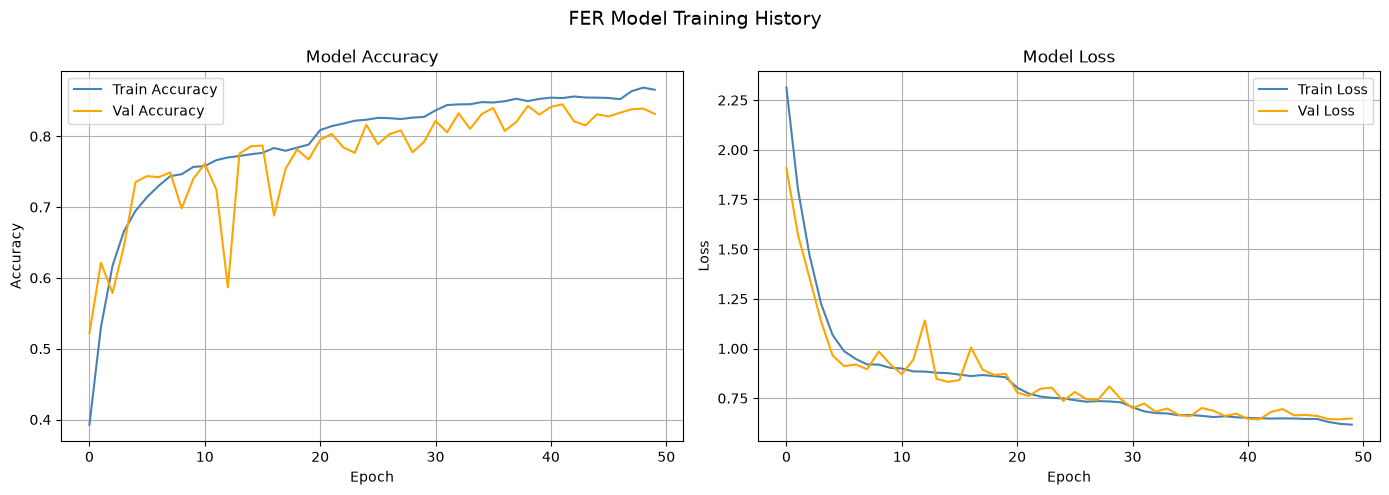

In [5]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss curve
ax2.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('FER Model Training History', fontsize=14)
plt.tight_layout()
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step


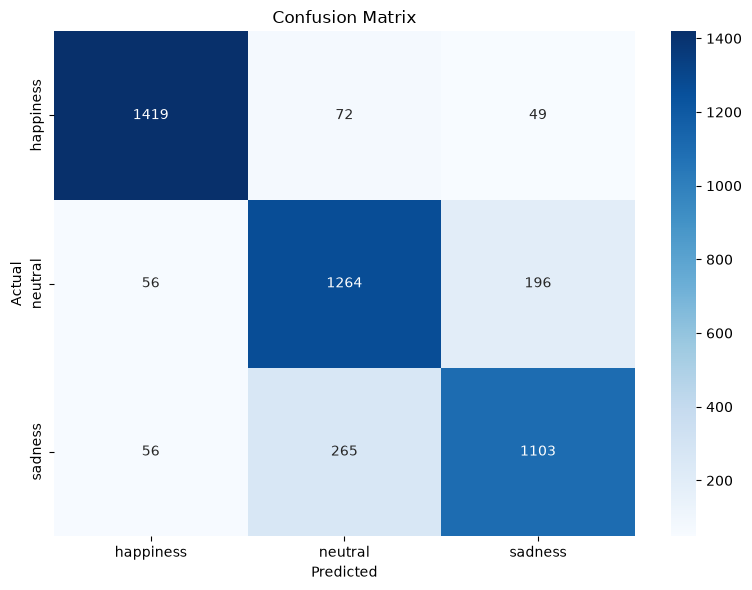


Classification Report:
              precision    recall  f1-score   support

   happiness       0.93      0.92      0.92      1540
     neutral       0.79      0.83      0.81      1516
     sadness       0.82      0.77      0.80      1424

    accuracy                           0.85      4480
   macro avg       0.84      0.84      0.84      4480
weighted avg       0.85      0.85      0.85      4480



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
import os

# Load best saved model
model_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\model\fer_best_model.keras"
best_model = load_model(model_path)

# Predict on test data
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

CLASSES = ['happiness', 'neutral', 'sadness']

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=CLASSES))